In [93]:
from kan import KAN
import torch
from torch.utils.data import DataLoader, TensorDataset
from MLP2layers import NeuralNetwork, test_loop, train_loop
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn

In [94]:
device = 'cpu'
model = NeuralNetwork().to(device)
layers = list(*model.children())
x = torch.linspace(-5,5,steps=500)[:,None].repeat(1,2)
print(model.state_dict())
# x = torch.randn(1000,2)

OrderedDict({'linear_relu_stack.0.weight': tensor([[-0.6123, -0.1334],
        [ 0.3193,  0.1099],
        [ 0.6000,  0.0324]]), 'linear_relu_stack.0.bias': tensor([-0.6571,  0.4075, -0.1322]), 'linear_relu_stack.2.weight': tensor([[0.5103, 0.3661, 0.0470]]), 'linear_relu_stack.2.bias': tensor([0.2894])})


In [95]:
kan = KAN(width=[2,3,1], seed=42, grid=15, scale_base_sigma=0)

checkpoint directory created: ./model
saving model version 0.0


In [96]:
kan.set_splines(x, modelPartitions=[layers[:1], layers[1:]])

[Linear(in_features=2, out_features=3, bias=True)]
[ReLU(), Linear(in_features=3, out_features=1, bias=True)]


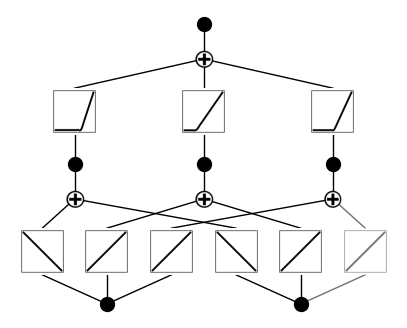

In [97]:
kan.plot(beta=100)

In [98]:
X_kan = torch.randn(10000,2)
y_kan = kan(X_kan)
y_kan_mean = y_kan.detach().numpy().mean()
print(y_kan_mean)
print(y_kan)

0.6273873
tensor([[0.5698],
        [0.6415],
        [0.5560],
        ...,
        [0.6687],
        [0.6558],
        [0.5902]], grad_fn=<AddBackward0>)


In [99]:
# X_train, X_test, y_train, y_test = train_test_split(X_kan.detach().numpy(), y_kan.detach().numpy(), test_size=0.2, random_state=42)
X_train = X_kan.detach().numpy()
y_train = y_kan.detach().numpy()
X_test = X_kan.detach().numpy()
y_test = y_kan.detach().numpy()

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create TensorDatasets and DataLoaders
train_dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
test_dataset = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

train_dataLoader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataLoader = DataLoader(test_dataset, batch_size=16, shuffle=False)

device = "cpu"  # change to 'cuda' if GPU is available

model = NeuralNetwork().to(device)
print(model)
print(model.state_dict())
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)

def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        pred = model(X)
        loss = loss_fn(pred, y)

        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # if batch % 100 == 0:
        #     loss, current = loss.item(), batch * 64 + len(X)
        #     print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test_loop(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss = 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
    test_loss /= num_batches
    print(f"Test loss: {test_loss:>7f}")
    print(abs(test_loss/y_kan_mean))


epochs = 500
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataLoader, model, loss_fn, optimizer)
    test_loop(test_dataLoader, model, loss_fn)




NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=2, out_features=3, bias=True)
    (1): ReLU()
    (2): Linear(in_features=3, out_features=1, bias=True)
  )
)
OrderedDict({'linear_relu_stack.0.weight': tensor([[-0.6288, -0.4364],
        [-0.6479,  0.0724],
        [-0.1902, -0.0077]]), 'linear_relu_stack.0.bias': tensor([ 0.2248,  0.1966, -0.1130]), 'linear_relu_stack.2.weight': tensor([[ 0.0921, -0.4718,  0.4432]]), 'linear_relu_stack.2.bias': tensor([-0.5057])})
Epoch 1
-------------------------------
Test loss: 0.002145
0.0034192095
Epoch 2
-------------------------------
Test loss: 0.001412
0.002250042
Epoch 3
-------------------------------
Test loss: 0.001053
0.0016782224
Epoch 4
-------------------------------
Test loss: 0.000872
0.001390344
Epoch 5
-------------------------------
Test loss: 0.000755
0.0012032714
Epoch 6
-------------------------------
Test loss: 0.000684
0.0010905158
Epoch 7
-------------------------------
Test loss: 0.000636
0.001

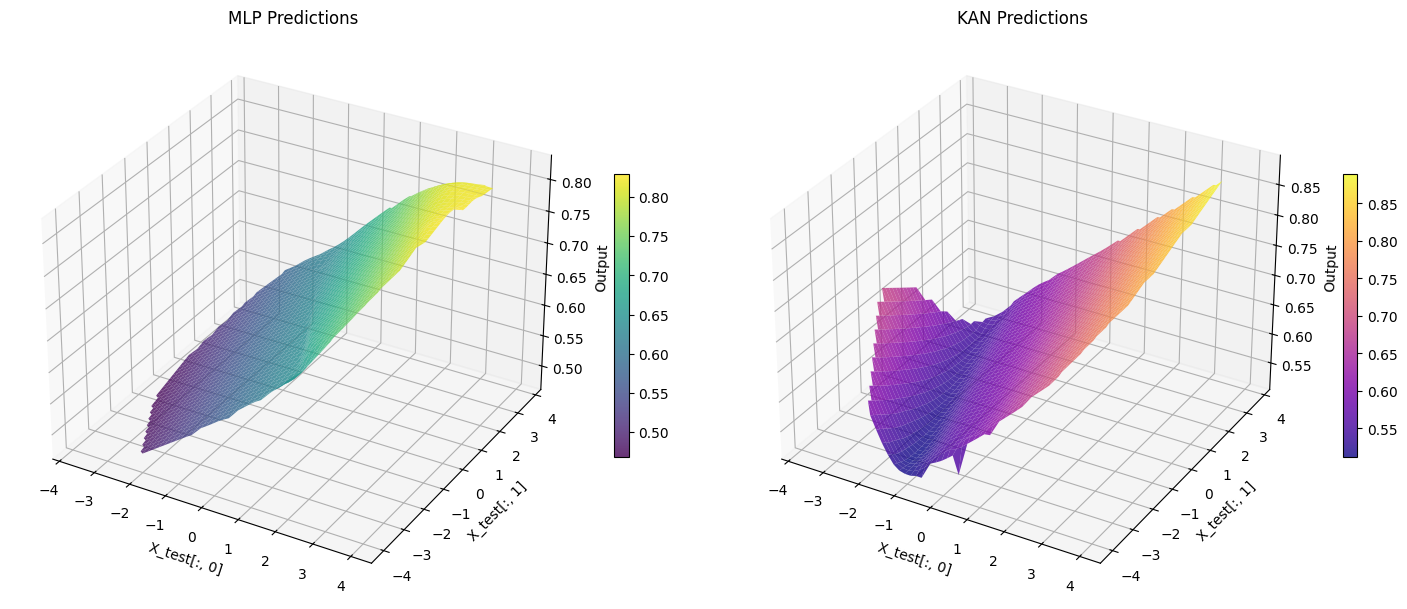

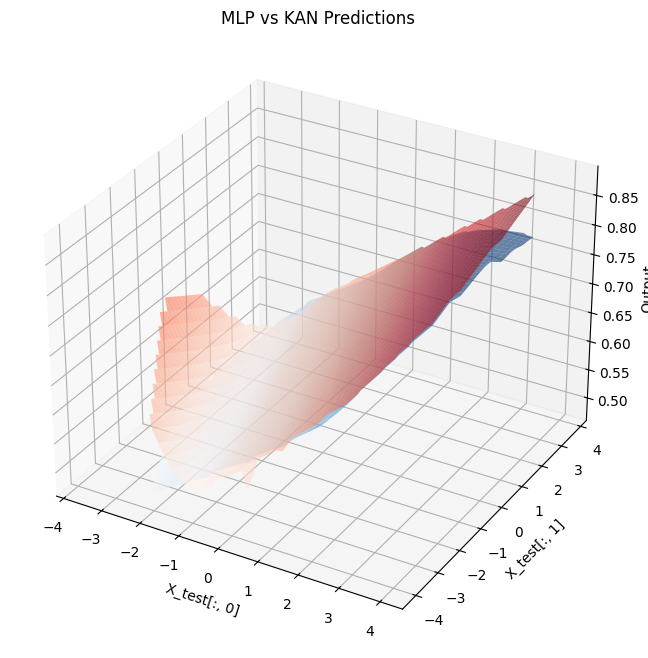

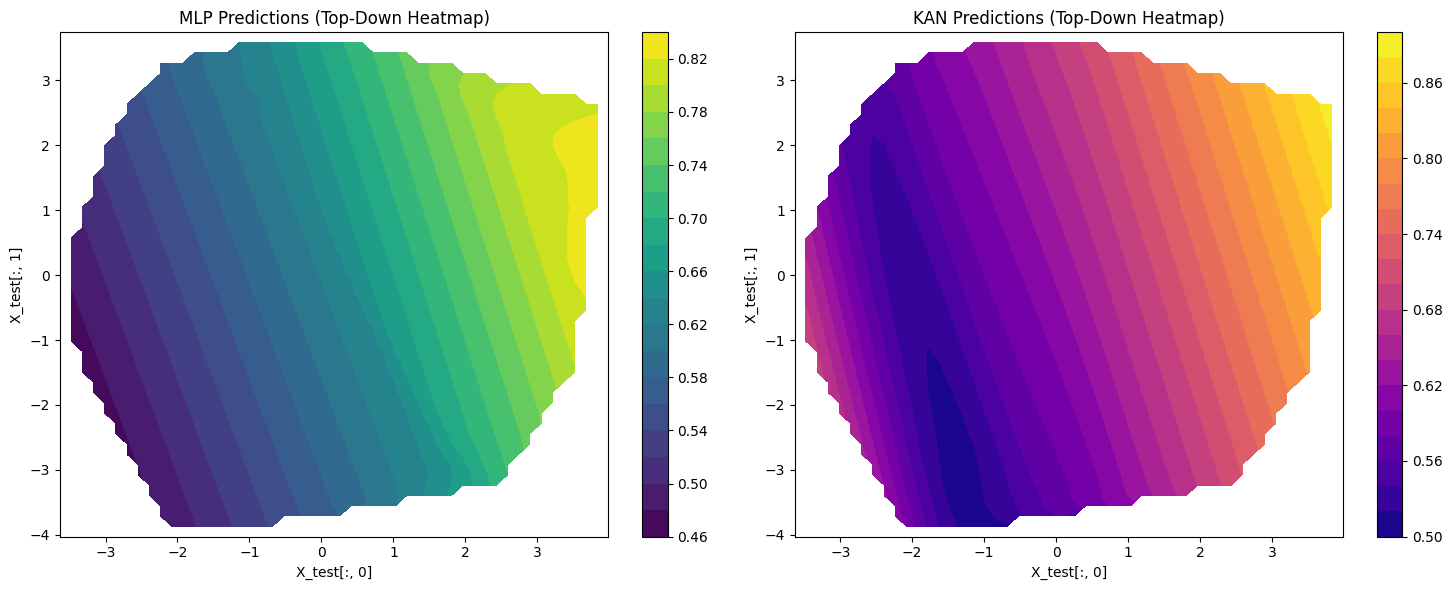

In [100]:
from scipy.interpolate import griddata
import numpy as np

import matplotlib.pyplot as plt

# Get predictions from both models
model.eval()
with torch.no_grad():
    X_test_tensor = torch.from_numpy(X_test).float()
    y_mlp = model(X_test_tensor).numpy().flatten()
    y_kan_pred = y_test.flatten()

# Create a grid for surface plotting
x0_range = np.linspace(X_test[:, 0].min(), X_test[:, 0].max(), 50)
x1_range = np.linspace(X_test[:, 1].min(), X_test[:, 1].max(), 50)
X0_grid, X1_grid = np.meshgrid(x0_range, x1_range)

# Interpolate data onto the grid
Y_mlp_grid = griddata((X_test[:, 0], X_test[:, 1]), y_mlp, (X0_grid, X1_grid), method='cubic')
Y_kan_grid = griddata((X_test[:, 0], X_test[:, 1]), y_kan_pred, (X0_grid, X1_grid), method='cubic')

# Create surface plots
fig = plt.figure(figsize=(15, 6))

# Plot 1: MLP predictions
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X0_grid, X1_grid, Y_mlp_grid, cmap='viridis', alpha=0.8)
ax1.set_xlabel('X_test[:, 0]')
ax1.set_ylabel('X_test[:, 1]')
ax1.set_zlabel('Output')
ax1.set_title('MLP Predictions')
fig.colorbar(surf1, ax=ax1, shrink=0.5)

# Plot 2: KAN predictions
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X0_grid, X1_grid, Y_kan_grid, cmap='plasma', alpha=0.8)
ax2.set_xlabel('X_test[:, 0]')
ax2.set_ylabel('X_test[:, 1]')
ax2.set_zlabel('Output')
ax2.set_title('KAN Predictions')
fig.colorbar(surf2, ax=ax2, shrink=0.5)

plt.tight_layout()
plt.show()

# Combined plot showing difference
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X0_grid, X1_grid, Y_mlp_grid, cmap='Blues', alpha=0.6, label='MLP')
ax.plot_surface(X0_grid, X1_grid, Y_kan_grid, cmap='Reds', alpha=0.6, label='KAN')
ax.set_xlabel('X_test[:, 0]')
ax.set_ylabel('X_test[:, 1]')
ax.set_zlabel('Output')
ax.set_title('MLP vs KAN Predictions')
plt.show()

# Create top-down heatmap views
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# MLP heatmap
im1 = ax1.contourf(X0_grid, X1_grid, Y_mlp_grid, levels=20, cmap='viridis')
ax1.set_xlabel('X_test[:, 0]')
ax1.set_ylabel('X_test[:, 1]')
ax1.set_title('MLP Predictions (Top-Down Heatmap)')
fig.colorbar(im1, ax=ax1)

# KAN heatmap
im2 = ax2.contourf(X0_grid, X1_grid, Y_kan_grid, levels=20, cmap='plasma')
ax2.set_xlabel('X_test[:, 0]')
ax2.set_ylabel('X_test[:, 1]')
ax2.set_title('KAN Predictions (Top-Down Heatmap)')
fig.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()

[Linear(in_features=2, out_features=3, bias=True)]
[ReLU(), Linear(in_features=3, out_features=1, bias=True)]


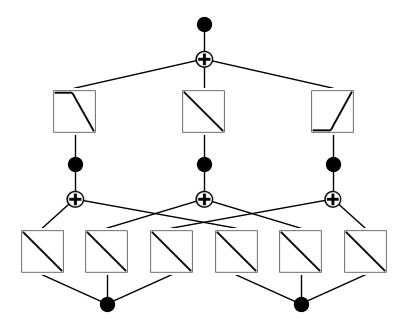

In [101]:
new_layers = list(*model.children())
kan.set_splines(x, modelPartitions=[new_layers[:1], new_layers[1:]])
kan.plot(beta=100)